<h1>UPI FRAUD ANALYTICS</h1>

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Loading Dataset
df = pd.read_csv('upi.csv')

<h2>DATA INFO</h2>

In [3]:
#Printing Dataset
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,08-10-2024 15:17,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,11-04-2024 06:56,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,02-04-2024 13:27,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,07-01-2024 10:09,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,23-01-2024 19:04,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [4]:
#Last 5 Rows
df.tail()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
249995,TXN0000249996,08-11-2024 22:41,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,HDFC,iOS,5G,0,22,Friday,0
249996,TXN0000249997,15-12-2024 02:58,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,Yes Bank,Android,5G,0,2,Sunday,1
249997,TXN0000249998,27-11-2024 16:33,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,ICICI,Android,4G,0,16,Wednesday,0
249998,TXN0000249999,05-01-2024 13:31,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,ICICI,iOS,4G,0,13,Friday,0
249999,TXN0000250000,17-01-2024 15:23,P2P,Entertainment,531,SUCCESS,18-25,26-35,Telangana,Axis,Yes Bank,Android,4G,0,15,Wednesday,0


In [6]:
#Shapes
df.shape

(250000, 17)

In [7]:
#Checking Columns Name
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [8]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

<h2>DATA ANALYSIS</h2>

In [5]:
#Statistical Summary
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


<h3>DATA CLEANING</h3>

In [10]:
#Cleaning Dataset
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [11]:
#Duplicate Values
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

<h1><center><font color="red">EXPLORATORY DAYA ANALYSIS</h1></font></center>

In [13]:
#Total Transaction Amount
df["amount (INR)"].sum()

np.int64(327939009)

In [6]:
#Average Transactions
df["amount (INR)"].mean()

np.float64(1311.756036)

In [7]:
#Maximum Transactions
df["amount (INR)"].max()

42099

In [8]:
#Minimum Transactions
df["amount (INR)"].min()

10

<h2><center>TRANSACTION TYPE ANALYSIS</center></h2>

In [9]:
#Transaction Analysis
df["transaction type"].value_counts()

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64

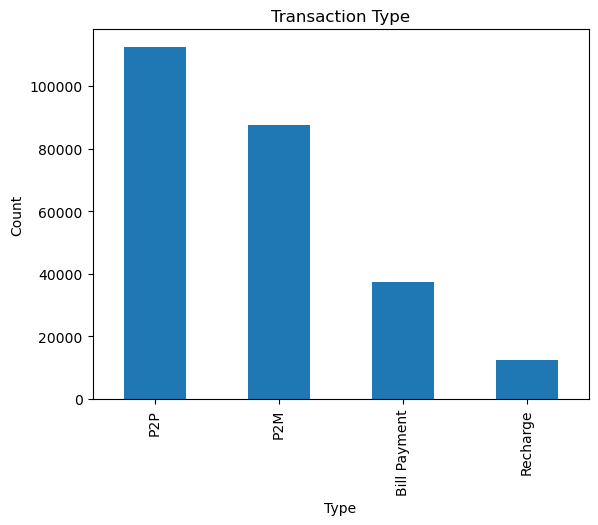

In [10]:
#Graphs
df["transaction type"].value_counts().plot(kind="bar")
plt.title("Transaction Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()
          

<h2><center>TRANSACTION STATUS</center></h2>

In [11]:
#Transaction status
df["transaction_status"].value_counts()

transaction_status
SUCCESS    237624
FAILED      12376
Name: count, dtype: int64

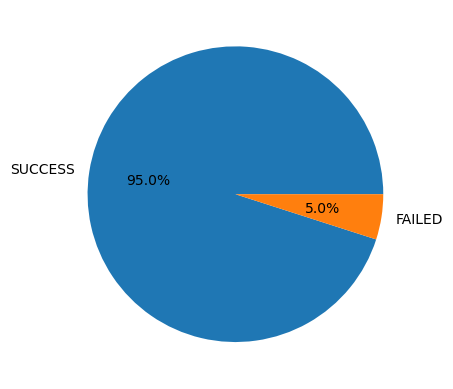

In [12]:
#Transaction Status Graphs
df["transaction_status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

<h2><center>MERCHANT CATEGORY</center></h2>

In [13]:
#Merchant Wise Category
df["merchant_category"].value_counts()

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64

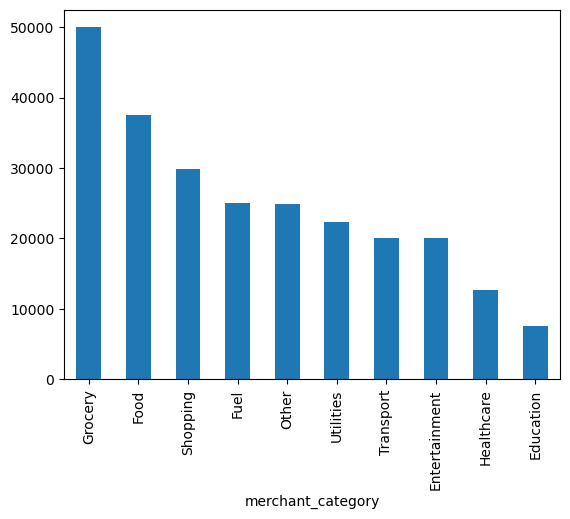

In [14]:
#Graphs
df["merchant_category"].value_counts().head(10).plot(kind="bar")
plt.show()

<h2><center>KPI CARDS</center></h2>

In [15]:
#Top KPI Cards
print("Total Transactions :", len(df))

print("Total Amount :", df["amount (INR)"].sum())

print("Average Amount :", df["amount (INR)"].mean())

print("Maximum Amount :", df["amount (INR)"].max())

print("Minimum Amount :", df["amount (INR)"].min())

Total Transactions : 250000
Total Amount : 327939009
Average Amount : 1311.756036
Maximum Amount : 42099
Minimum Amount : 10


<h2><center>STATE WISE TRANSACTIONS</center></h2>

In [16]:
df["sender_state"].value_counts()

sender_state
Maharashtra       37427
Uttar Pradesh     30125
Karnataka         29756
Tamil Nadu        25367
Delhi             24870
Telangana         22435
Gujarat           20061
Andhra Pradesh    20006
Rajasthan         19981
West Bengal       19972
Name: count, dtype: int64

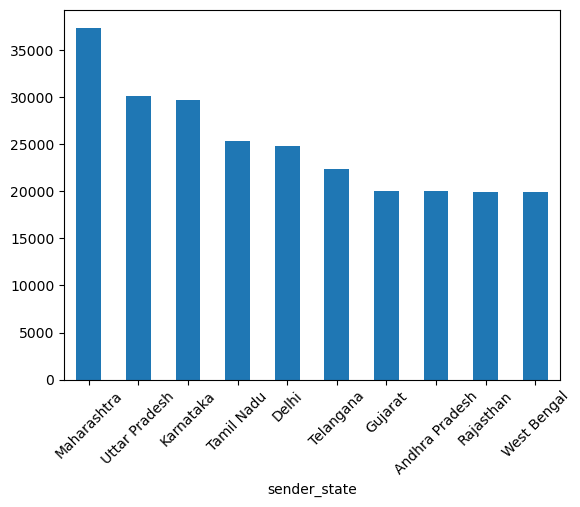

In [17]:
df["sender_state"].value_counts().head(10).plot(kind="bar")

plt.xticks(rotation=45)

plt.show()

<h2><center>HOUR WISE TRANSACTIONS</center></h2>

In [18]:
#Hour Wise Transactions
df.groupby("hour_of_day")["amount (INR)"].sum()

hour_of_day
0      4532884
1      2914350
2      2173750
3      1678669
4      1670700
5      2134122
6      4617034
7      7482766
8     10979614
9     13809021
10    18337313
11    21193161
12    23406280
13    19847819
14    14848621
15    16658144
16    17921125
17    24514186
18    26297174
19    28223522
20    23822014
21    20995491
22    12050824
23     7830425
Name: amount (INR), dtype: int64

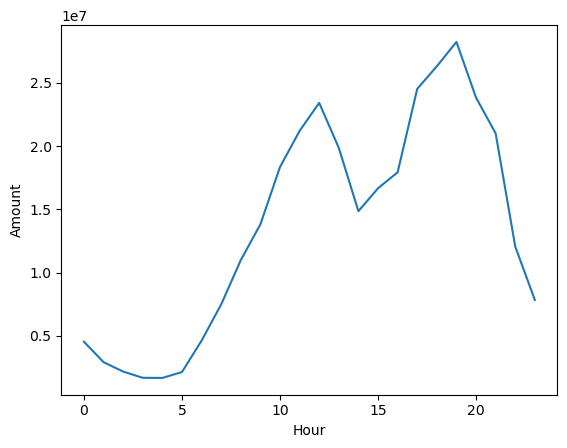

In [19]:
df.groupby("hour_of_day")["amount (INR)"].sum().plot()
plt.xlabel("Hour")
plt.ylabel("Amount")
plt.show()

<h2><center>DAY WISE TRANSACTIONS</center></h2>

In [20]:
df["day_of_week"].value_counts()

day_of_week
Monday       36495
Sunday       36003
Wednesday    35700
Tuesday      35540
Friday       35496
Thursday     35432
Saturday     35334
Name: count, dtype: int64

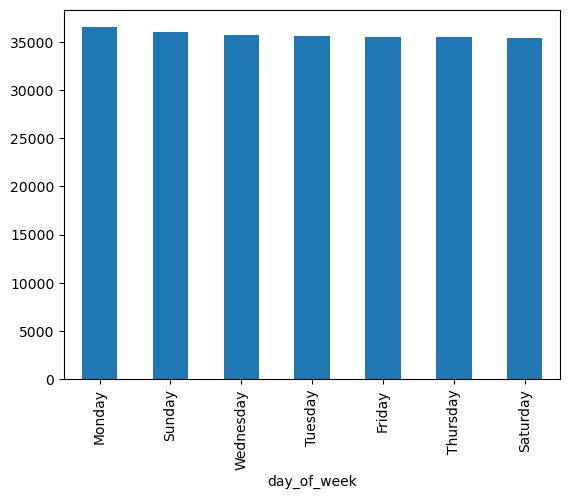

In [21]:
df["day_of_week"].value_counts().plot(kind="bar")
plt.show()

<h2><center>TOP 10 TRANSACTIONS</center></h2>

In [22]:
#Top 10 transactions
df.nlargest(10,"amount (INR)")

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
144868,TXN0000144869,12-05-2024 01:26,P2P,Education,42099,FAILED,46-55,26-35,Telangana,IndusInd,IndusInd,Android,4G,0,1,Sunday,1
233820,TXN0000233821,21-12-2024 14:43,Bill Payment,Education,41210,SUCCESS,26-35,26-35,Maharashtra,HDFC,ICICI,Android,4G,0,14,Saturday,1
195366,TXN0000195367,09-07-2024 22:28,Recharge,Education,37263,SUCCESS,36-45,26-35,Rajasthan,Axis,Axis,Android,WiFi,0,22,Tuesday,0
72465,TXN0000072466,23-08-2024 17:51,P2P,Education,34304,SUCCESS,36-45,26-35,Andhra Pradesh,PNB,Axis,Android,5G,0,17,Friday,0
25258,TXN0000025259,09-12-2024 23:36,P2P,Education,33061,SUCCESS,36-45,26-35,Rajasthan,Yes Bank,HDFC,Android,WiFi,0,23,Monday,0
142496,TXN0000142497,08-03-2024 17:30,P2P,Education,32741,SUCCESS,46-55,26-35,West Bengal,Yes Bank,SBI,Android,WiFi,0,17,Friday,0
214955,TXN0000214956,03-01-2024 20:49,P2P,Education,30584,SUCCESS,36-45,26-35,Andhra Pradesh,Kotak,Axis,Android,5G,0,20,Wednesday,0
121682,TXN0000121683,17-07-2024 23:31,P2P,Utilities,30351,SUCCESS,26-35,26-35,West Bengal,HDFC,HDFC,iOS,WiFi,0,23,Wednesday,0
162783,TXN0000162784,14-10-2024 21:26,P2M,Education,30112,SUCCESS,36-45,36-45,Telangana,HDFC,SBI,Android,5G,0,21,Monday,0
223738,TXN0000223739,10-09-2024 07:45,P2M,Education,29601,SUCCESS,46-55,18-25,Uttar Pradesh,SBI,Axis,Android,3G,0,7,Tuesday,0


<h2><center>LOWEST 10 TRANSACTIONS</center></h2>

In [23]:
#Lowest Transactions
df.nsmallest(10,"amount (INR)")

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
12720,TXN0000012721,05-02-2024 09:52,P2P,Food,10,SUCCESS,46-55,26-35,Uttar Pradesh,Yes Bank,Kotak,iOS,4G,0,9,Monday,0
133929,TXN0000133930,02-07-2024 19:37,Bill Payment,Transport,10,SUCCESS,26-35,36-45,Telangana,PNB,IndusInd,Android,4G,0,19,Tuesday,0
11255,TXN0000011256,04-04-2024 21:40,P2P,Transport,11,SUCCESS,56+,18-25,Karnataka,Yes Bank,SBI,iOS,5G,0,21,Thursday,0
243528,TXN0000243529,30-12-2024 19:57,P2P,Food,11,SUCCESS,36-45,36-45,Delhi,HDFC,Axis,Android,4G,0,19,Monday,0
111941,TXN0000111942,09-06-2024 00:59,P2M,Transport,12,SUCCESS,56+,18-25,West Bengal,Axis,Yes Bank,Android,4G,0,0,Sunday,1
212334,TXN0000212335,27-02-2024 19:44,P2M,Transport,12,SUCCESS,26-35,18-25,Gujarat,SBI,HDFC,Android,4G,0,19,Tuesday,0
49978,TXN0000049979,14-09-2024 02:48,P2M,Transport,13,SUCCESS,36-45,18-25,Uttar Pradesh,Kotak,HDFC,iOS,4G,0,2,Saturday,1
105960,TXN0000105961,19-10-2024 19:07,P2P,Transport,13,SUCCESS,56+,36-45,Andhra Pradesh,Yes Bank,HDFC,iOS,4G,0,19,Saturday,1
124724,TXN0000124725,05-05-2024 21:17,P2M,Transport,13,SUCCESS,46-55,18-25,Delhi,SBI,PNB,Android,4G,0,21,Sunday,1
152237,TXN0000152238,21-02-2024 06:36,P2P,Transport,13,FAILED,36-45,56+,Tamil Nadu,Yes Bank,SBI,Android,4G,0,6,Wednesday,0


<h2><center>FRAUD VS AMOUNT</center></h2>

In [26]:
df.groupby("fraud_flag")["amount (INR)"].mean()

fraud_flag
0    1311.395391
1    1499.231250
Name: amount (INR), dtype: float64